In [34]:
import random
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

SEED = 42
random.seed(SEED)

The EMit dataset is a comprehensive resource for the detection of emotions in Italian social media texts. This dataset was created for the EMit shared task, organized as part of Evalita 2023. The EMit dataset consists of social media messages about TV shows, TV series, music videos, and advertisements. Each message is annotated with one or more of the 8 primary emotions defined by Plutchik (anger, anticipation, disgust, fear, joy, sadness, surprise, trust), as well as an additional label “love.”
#https://huggingface.co/datasets/MattiaSangermano/emit

In [58]:
ds1 = load_dataset("MattiaSangermano/emit")
print(ds1)
print('='*90)

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'emotion_labels', 'target_labels'],
        num_rows: 5966
    })
    test: Dataset({
        features: ['id', 'text', 'emotion_labels', 'target_labels'],
        num_rows: 1000
    })
    test_ood: Dataset({
        features: ['id', 'text', 'emotion_labels', 'target_labels'],
        num_rows: 1000
    })
})


Reducing the emotion label to positive - neutral - negative for specific sentiment analysis and data collection

In [3]:
label_mapping = {
    0: 0,
    2: 0,
    3: 0,
    4: 1,
    5: 1,
    6: 1,
    7: 0,
    9: 2
}
def get_text_and_labels(dataset, label_mapping):
  texts = []
  labels = []

  for x in dataset:
    if len(x["emotion_labels"]) > 1:
      continue
    if x["emotion_labels"][0] not in label_mapping.keys():
      continue
    if x["emotion_labels"][0] in label_mapping.keys():
      emotion = x["emotion_labels"][0]
      labels.append(label_mapping[emotion])
      texts.append(x["text"])
  return texts, labels

In [4]:
train_texts_ds1, train_labels_ds1 = get_text_and_labels(ds1["train"], label_mapping)
test_texts_ds1, test_labels_ds1 = get_text_and_labels(ds1["test"], label_mapping)
print("--- Stats for ds1 (MattiaSangermano/emit) ---")
print("Num di elementi nel TRAIN_SET:", len(train_labels_ds1))
train_label_counts_ds1 = Counter(train_labels_ds1)
print("Distribuzione delle label nel TRAIN_SET:")
print(train_label_counts_ds1)
print("="*90)
print("Num di elementi nel TEST_SET:", len(test_labels_ds1))
test_label_counts_ds1 = Counter(test_labels_ds1)
print("Distribuzione delle label nel TEST_SET:")
print(test_label_counts_ds1)
print("="*90)

--- Stats for ds1 (MattiaSangermano/emit) ---
Num di elementi nel TRAIN_SET: 4056
Distribuzione delle label nel TRAIN_SET:
Counter({1: 1922, 2: 1086, 0: 1048})
Num di elementi nel TEST_SET: 695
Distribuzione delle label nel TEST_SET:
Counter({1: 315, 0: 197, 2: 183})


Vector and MLP pipeline. Easy, fast and discrete local solution for a simple classifier

In [5]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
    lowercase=True,
    strip_accents='unicode'
)

In [6]:
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    batch_size=64,
    learning_rate_init=1e-3,
    max_iter=30,
    early_stopping=True,
    n_iter_no_change=3,
    random_state=SEED,
    verbose=True
)

In [7]:
pipeline = Pipeline([
    ("tfidf", tfidf),
    ("mlp", mlp)
])

pipeline

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, min_df=2,
                                 ngram_range=(1, 2), strip_accents='unicode')),
                ('mlp',
                 MLPClassifier(batch_size=64, early_stopping=True,
                               hidden_layer_sizes=(256, 128), max_iter=30,
                               n_iter_no_change=3, random_state=42,
                               verbose=True))])

In [8]:
pipeline.fit(train_texts_ds1, train_labels_ds1)
print("="*90)
loss_curve = pipeline.named_steps["mlp"].loss_curve_
print(f"Numero di epoche di training: {len(loss_curve)}")

print("\n" + "="*90 + "\n")
print("=== Classification Report per dataset ===")

id2label_ds1 = {0:"negativo", 1:"positivo", 2: "neutro"}
labels_ds1 = sorted(id2label_ds1.keys())
target_names_ds1 = [id2label_ds1[i] for i in sorted(id2label_ds1.keys())]

MLP_test_prediction_ds1_trained_on_ds1 = pipeline.predict(test_texts_ds1)

MLP_test_report_ds1_bsln = classification_report(
    test_labels_ds1,
    MLP_test_prediction_ds1_trained_on_ds1,
    labels=labels_ds1,
    target_names=target_names_ds1,
    output_dict=True
)
df_MLP_test_class_report_ds1_bsln = pd.DataFrame(MLP_test_report_ds1_bsln).transpose()

print(df_MLP_test_class_report_ds1_bsln)
print("\n" + "="*90 + "\n")

Iteration 1, loss = 1.03149956
Validation score: 0.477833
Iteration 2, loss = 0.66588455
Validation score: 0.596059
Iteration 3, loss = 0.24678217
Validation score: 0.576355
Iteration 4, loss = 0.10006487
Validation score: 0.568966
Iteration 5, loss = 0.06622405
Validation score: 0.581281
Iteration 6, loss = 0.05224252
Validation score: 0.568966
Validation score did not improve more than tol=0.000100 for 3 consecutive epochs. Stopping.
Numero di epoche di training: 6


=== Classification Report per dataset ===
              precision    recall  f1-score     support
negativo       0.613333  0.467005  0.530259  197.000000
positivo       0.626822  0.682540  0.653495  315.000000
neutro         0.539604  0.595628  0.566234  183.000000
accuracy       0.598561  0.598561  0.598561    0.598561
macro avg      0.593253  0.581724  0.583330  695.000000
weighted avg   0.600033  0.598561  0.595587  695.000000




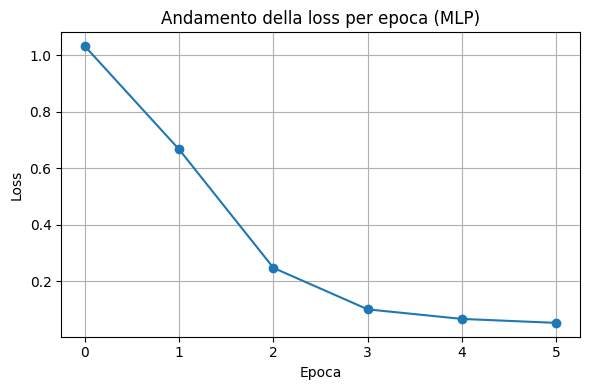

In [9]:
plt.figure(figsize=(6,4))
plt.plot(loss_curve, marker='o')
plt.title("Andamento della loss per epoca (MLP)")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
id2label_ds1 = {0:"negativo", 1:"positivo", 2: "neutro"}
rng = random.Random(SEED)

print("=== Esempi di predizioni per dataset (MattiaSangermano/emit) ===\n")
idx_sample_ds1 = rng.sample(range(len(test_texts_ds1)), 10)
for i in idx_sample_ds1:
  txt = test_texts_ds1[i]
  gold = test_labels_ds1[i]
  pred = list(pipeline.predict([txt]))[0]

  print("="*90)
  print(f"Testo:  {txt}")
  print(f"Gold:   {gold} - {id2label_ds1.get(gold, 'Sconosciuto')}")
  print(f"Predetto:  {pred} - {id2label_ds1.get(pred, 'Sconosciuto')}")

=== Esempi di predizioni per dataset (MattiaSangermano/emit) ===

Testo:  Martina e Mario avranno pure fatto pace alla fine del programma,ma il comportamento di Martina fa solo schifo. È una bulla. #IlCollegio
Gold:   0 - negativo
Predetto:  0 - negativo
Testo:  Peccato che nel 2016 la trovai chiusa la via Krupp! #Meraviglie
Gold:   0 - negativo
Predetto:  0 - negativo
Testo:  TIÉ! Confermata la condanna a 20 anni. Godo come una scrofa in calore. #chilhavisto
Gold:   1 - positivo
Predetto:  1 - positivo
Testo:  Asia Argento agguerrita e acidissima. Soleil e sua madre super stronze. Enzo Miccio che dà giudizi spietati sui look dei concorrenti.  Già adoroh.  #pechinoexpress https://t.co/HYczw7gfB8
Gold:   1 - positivo
Predetto:  2 - neutro
Testo:  RT @user: "Vorrei che per una volta fosse lui a fare un passo verso di me" AHAHAHAHHAHAHAHAHAAHAHHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHH…
Gold:   1 - positivo
Predetto:  2 - neutro
Testo:  RT @user: Anna Tantangelo meriti di più MERITI DI PIÙ #dom

In [11]:
from sklearn.metrics import classification_report

MLP_test_labels_ds1 = test_labels_ds1
MLP_test_prediction_ds1 = pipeline.predict(test_texts_ds1)
labels_ds1 = sorted(id2label_ds1.keys())
target_names_ds1 = [id2label_ds1[i] for i in sorted(id2label_ds1.keys())]


Creating a baseline to test the efficiency of each model

In [12]:
import random
baseline_pred = []
s_list = []
for t in test_labels_ds1:
  random_label = random.choice(labels_ds1)
  baseline_pred.append(random_label)
print("=== Baseline for dataset (MattiaSangermano/emit) ===")
baseline_report = classification_report(
    MLP_test_labels_ds1,
    baseline_pred,
    labels=labels_ds1,
    target_names=target_names_ds1,
    output_dict=True
)
df_baseline_report = pd.DataFrame(baseline_report).transpose()
print(df_baseline_report)
print("\n" + "="*90 + "\n")


=== Baseline for dataset (MattiaSangermano/emit) ===
              precision    recall  f1-score    support
negativo       0.278008  0.340102  0.305936  197.00000
positivo       0.439252  0.298413  0.355388  315.00000
neutro         0.270833  0.355191  0.307329  183.00000
accuracy       0.325180  0.325180  0.325180    0.32518
macro avg      0.329365  0.331235  0.322884  695.00000
weighted avg   0.349201  0.325180  0.328716  695.00000




=== Classification Report for dataset (MattiaSangermano/emit) ===
              precision    recall  f1-score     support
negativo       0.613333  0.467005  0.530259  197.000000
positivo       0.626822  0.682540  0.653495  315.000000
neutro         0.539604  0.595628  0.566234  183.000000
accuracy       0.598561  0.598561  0.598561    0.598561
macro avg      0.593253  0.581724  0.583330  695.000000
weighted avg   0.600033  0.598561  0.595587  695.000000




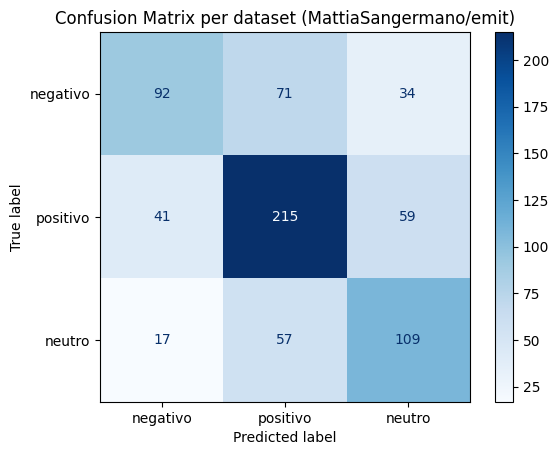

In [13]:
print("=== Classification Report for dataset (MattiaSangermano/emit) ===")
MLP_test_report_ds1 = classification_report(
    MLP_test_labels_ds1,
    MLP_test_prediction_ds1,
    labels=labels_ds1,
    target_names=target_names_ds1,
    output_dict=True
)
df_MLP_test_class_report_ds1 = pd.DataFrame(MLP_test_report_ds1).transpose()
print(df_MLP_test_class_report_ds1)
print("\n" + "="*90 + "\n")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_ds1 = confusion_matrix(MLP_test_labels_ds1, MLP_test_prediction_ds1, labels=labels_ds1)
disp_ds1 = ConfusionMatrixDisplay(confusion_matrix=cm_ds1, display_labels=target_names_ds1)
disp_ds1.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix per dataset (MattiaSangermano/emit)')
plt.show()

In [14]:
print("=== Proporzioni delle label per ds1 (MattiaSangermano/emit) ===")
print("--- TRAIN_SET ---")
total_train_ds1 = len(train_labels_ds1)
for label, count in train_label_counts_ds1.items():
    print(f"Label {label} ({id2label_ds1.get(label, 'Sconosciuto')}): {count}/{total_train_ds1} ({count/total_train_ds1:.2%})")

print("\n--- TEST_SET ---")
total_test_ds1 = len(test_labels_ds1)
for label, count in test_label_counts_ds1.items():
    print(f"Label {label} ({id2label_ds1.get(label, 'Sconosciuto')}): {count}/{total_test_ds1} ({count/total_test_ds1:.2%})")
print("="*90)

=== Proporzioni delle label per ds1 (MattiaSangermano/emit) ===
--- TRAIN_SET ---
Label 1 (positivo): 1922/4056 (47.39%)
Label 2 (neutro): 1086/4056 (26.78%)
Label 0 (negativo): 1048/4056 (25.84%)

--- TEST_SET ---
Label 0 (negativo): 197/695 (28.35%)
Label 2 (neutro): 183/695 (26.33%)
Label 1 (positivo): 315/695 (45.32%)


# neuraly - Italian BERT Sentiment model
Model trained on social media post - different dataset same language and variety
https://huggingface.co/neuraly/bert-base-italian-cased-sentiment

In [15]:
!pip -q install transformers torch

In [16]:
from transformers import pipeline
from sklearn.metrics import classification_report
import pandas as pd
from tqdm import tqdm

In [17]:
bert_sentiment = pipeline(
    task="text-classification",
    model="neuraly/bert-base-italian-cased-sentiment",
    device=0
)

config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/40.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/235k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [18]:
bert_label_map = {
    "negative": 0,
    "neutral":  2,
    "positive": 1
}

In [19]:
def bert_predict(texts, batch_size=32):
    predictions = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Predicting"):
        batch = texts[i : i + batch_size]
        results = bert_sentiment(batch, truncation=True, max_length=512)
        for r in results:
            predictions.append(bert_label_map[r["label"]])
    return predictions

In [20]:
print("Predizione su ds1 (EMIT)...")
bert_preds = bert_predict(test_texts_ds1)

Predizione su ds1 (EMIT)...


Predicting: 100%|██████████| 22/22 [02:01<00:00,  5.54s/it]


=== BERT — Classification Report su ds1 ===
              precision    recall  f1-score     support
negativo       0.789474  0.304569  0.439560  197.000000
positivo       0.326389  0.149206  0.204793  315.000000
neutro         0.210526  0.546448  0.303951  183.000000
accuracy       0.297842  0.297842  0.297842    0.297842
macro avg      0.442130  0.333408  0.316102  695.000000
weighted avg   0.427144  0.297842  0.297448  695.000000


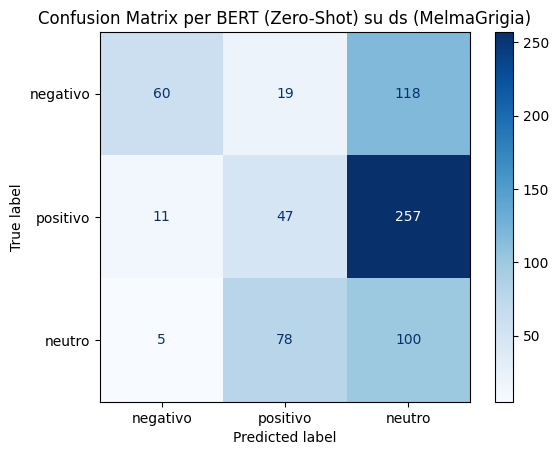

In [21]:
id2label_ds1   = {0: "negativo", 1: "positivo", 2: "neutro"}
labels_ds1     = sorted(id2label_ds1.keys())
names_ds1      = [id2label_ds1[i] for i in labels_ds1]

bert_report_ds1 = classification_report(
    test_labels_ds1,
    bert_preds,
    labels=labels_ds1,
    target_names=names_ds1,
    output_dict=True
)
df_bert_ds1 = pd.DataFrame(bert_report_ds1).transpose()
print("=== BERT — Classification Report su ds1 ===")
print(df_bert_ds1)

cm_bert_ds1 = confusion_matrix(test_labels_ds1, bert_preds, labels=labels_ds1)
disp_bert_ds1 = ConfusionMatrixDisplay(confusion_matrix=cm_bert_ds1, display_labels=names_ds1)
disp_bert_ds1.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix per BERT (Zero-Shot) su ds (MelmaGrigia)')
plt.show()

# Llama 4 Scout via Groq
### Groq:
High token limit rate for free
### Llama 4:
Newer and faster non reasoning model

*Tested on gpt-oss:120b, the reasoning consume to many token and lead to huge text generation without the predictions - non parsal prediction*

In [22]:
!pip -q install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.4 MB/s eta 0:00:00


In [72]:
from groq import Groq
import re, time
from tqdm import tqdm

GROQ_API_KEY = "gsk_********************************"
client_groq  = Groq(api_key=GROQ_API_KEY)

SYSTEM_PROMPT_LLAMA = """Sei un classificatore di sentiment per l'italiano.
Classifica il sentiment del testo fornito.
Rispondi SOLO con una parola: negativo, positivo, oppure neutro.
Nessuna spiegazione, nessun testo aggiuntivo."""

llama_label_map = {"negativo": 0, "positivo": 1, "neutro": 2}

In [50]:
import re, time
from tqdm import tqdm

LABEL_PATTERNS = [
    (re.compile(r'negat'),  0),
    (re.compile(r'posit'),  1),
    (re.compile(r'neutr'),  2),
]

def parse_label(raw: str) -> int:

    cleaned = raw.strip().lower()
    cleaned = re.sub(r'[^\w àèéìòù]', '', cleaned)
    for pattern, label in LABEL_PATTERNS:
        if pattern.search(cleaned):
            return label
    return -1

def groq_predict_single(text: str, retries: int = 3) -> int:
    for attempt in range(retries):
        try:
            response = client_groq.chat.completions.create(
                model="meta-llama/llama-4-scout-17b-16e-instruct",
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT_LLAMA},
                    {"role": "user",   "content": f"Testo: \"{text[:400]}\"\nSentiment:"}
                ],
                max_tokens=10,
                temperature=0.0,
            )
            raw = response.choices[0].message.content
            label = parse_label(raw)
            if label != -1:
                return label
            print(f"\n  [WARN] risposta non parsabile: {repr(raw)}")
        except Exception as e:
            print(f"\n  [ERR] tentativo {attempt+1}/{retries}: {e}")
            if attempt < retries - 1:
                time.sleep(2 ** attempt)
    return -1

def groq_predict(texts: list, delay: float = 0.1) -> list:
    predictions = []
    n_errors = 0

    bar = tqdm(texts, desc="Llama 4 Scout [Groq]")
    for text in bar:
        pred = groq_predict_single(text)
        predictions.append(pred)

        if pred == -1:
            n_errors += 1

        bar.set_postfix({"errori(-1)": n_errors, "tot": len(predictions)})
        time.sleep(delay)

    print(f"\n{'='*60}")
    print(f"Completato: {len(predictions)} predizioni")
    print(f"  ✅ Valide:  {len(predictions) - n_errors}")
    print(f"  ❌ Errori:  {n_errors}  ({n_errors/len(predictions):.1%})")
    print(f"{'='*60}")
    return predictions




In [51]:
print(f"Test set ds1: {len(test_texts_ds1)} esempi\n")
llama_preds_ds1 = groq_predict(test_texts_ds1)

Test set ds1: 695 esempi



Llama 4 Scout [Groq]: 100%|██████████| 695/695 [26:49<00:00,  2.32s/it, errori(-1)=0, tot=695]


Completato: 695 predizioni
  ✅ Valide:  695
  ❌ Errori:  0  (0.0%)


In [55]:
from pandas import DataFrame
df_llama_ds1 = eval_report(
    llama_preds_ds1, test_labels_ds1,
    {0: "negativo", 1: "positivo", 2: "neutro"}
)
n_valid_ds1 = sum(p != -1 for p in llama_preds_ds1)
print(f"=== Llama 4 Scout [Groq] — ds1  ({n_valid_ds1}/{len(test_texts_ds1)} valide) ===")
print(df_llama_ds1)
print()

=== Llama 4 Scout [Groq] — ds1  (695/695 valide) ===
              precision    recall  f1-score     support
negativo       0.621908  0.893401  0.733333  197.000000
positivo       0.427083  0.390476  0.407960  315.000000
neutro         0.088710  0.060109  0.071661  183.000000
accuracy       0.446043  0.446043  0.446043    0.446043
macro avg      0.379234  0.447995  0.404318  695.000000
weighted avg   0.393210  0.446043  0.411638  695.000000



In [56]:
def macro_f1(df_report):
    return df_report.loc["macro avg", "f1-score"]
comparison = pd.DataFrame({
    "Modello": [
        "TF-IDF + MLP (baseline, ds1)",
        "BERT italiano (zero-shot)",
        "llama-4-scout-17b-16e-instruct (zero-shot, Groq)"
    ],
    "F1-macro ds1": [
        macro_f1(df_MLP_test_class_report_ds1),
        macro_f1(df_bert_ds1),
        macro_f1(df_llama_ds1)
    ],
    "Tipo":           ["Supervised", "Zero-shot", "Zero-shot"],
    "Training su":    ["ds1",  "nessuno",   "nessuno"],
    "Test set usato": ["completo",   "completo",  "completo"]
})

print("=== CONFRONTO FINALE ===\n")
print(comparison.to_string(index=False))

=== CONFRONTO FINALE ===

                                         Modello  F1-macro ds1       Tipo Training su Test set usato
                    TF-IDF + MLP (baseline, ds1)      0.583330 Supervised         ds1       completo
                       BERT italiano (zero-shot)      0.316102  Zero-shot     nessuno       completo
llama-4-scout-17b-16e-instruct (zero-shot, Groq)      0.404318  Zero-shot     nessuno       completo


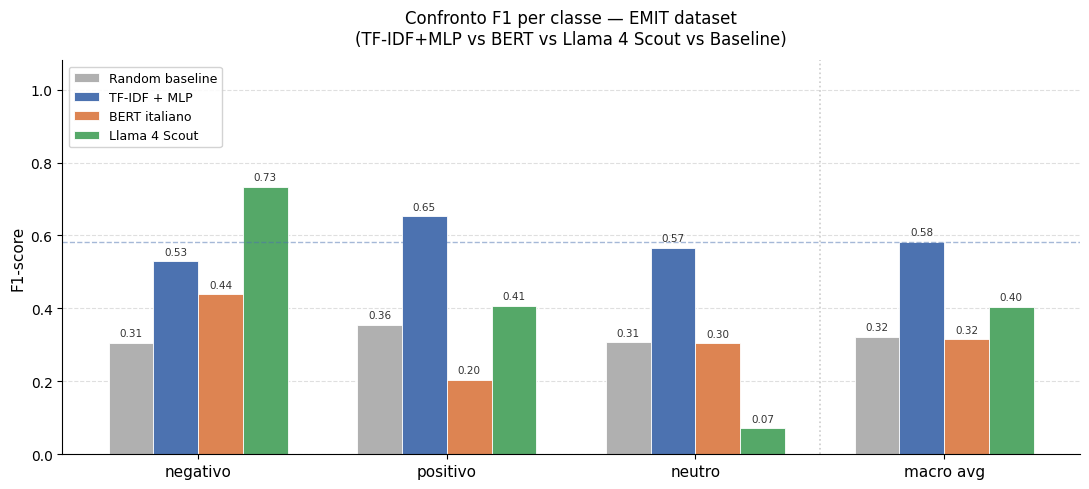

In [57]:
import matplotlib.pyplot as plt
import numpy as np

def extract_f1_row(df, classes=["negativo", "positivo", "neutro"]):
    row = [df.loc[c, "f1-score"] for c in classes]
    row.append(df.loc["macro avg", "f1-score"])
    return row

classes_ext = ["negativo", "positivo", "neutro", "macro avg"]

f1_baseline = extract_f1_row(df_baseline_report)
f1_mlp      = extract_f1_row(df_MLP_test_class_report_ds1)
f1_bert     = extract_f1_row(df_bert_ds1)
f1_llama    = extract_f1_row(df_llama_ds1)

models  = ["Random baseline", "TF-IDF + MLP", "BERT italiano", "Llama 4 Scout"]
scores  = [f1_baseline, f1_mlp, f1_bert, f1_llama]
colors  = ["#b0b0b0", "#4c72b0", "#dd8452", "#55a868"]

x      = np.arange(len(classes_ext))
n      = len(models)
width  = 0.18
offset = np.linspace(-(n-1)/2, (n-1)/2, n) * width

fig, ax = plt.subplots(figsize=(11, 5))

for i, (model, score, color) in enumerate(zip(models, scores, colors)):
    bars = ax.bar(x + offset[i], score, width, label=model,
                  color=color, edgecolor="white", linewidth=0.6)
    for bar, val in zip(bars, score):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.012,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=7.5, color="#333333")

ax.axhline(f1_mlp[-1], color=colors[1], linewidth=1,
           linestyle="--", alpha=0.5, label="_nolegend_")

ax.axvline(len(classes_ext) - 1 - 0.5, color="#cccccc",
           linewidth=1.2, linestyle=":")

ax.set_xticks(x)
ax.set_xticklabels(classes_ext, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel("F1-score", fontsize=11)
ax.set_title("Confronto F1 per classe — EMIT dataset\n"
             "(TF-IDF+MLP vs BERT vs Llama 4 Scout vs Baseline)",
             fontsize=12, pad=12)
ax.legend(loc="upper left", fontsize=9, framealpha=0.85)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("confronto_f1_finale.png", dpi=150, bbox_inches="tight")
plt.show()

##Final toughts:
TF-IDF + MLP: Fastest, cheaper and data safety assured solution. Must follow up with training on negative emotion recognition

#Playful test to delegate the summary to GPT-oss:

In [71]:
mlp_report_summary = (
    f"MLP Classifier Report:\n"
    f"  Accuracy: {df_MLP_test_class_report_ds1.loc['accuracy', 'f1-score']:.2f}\n"
    f"  Macro Avg: P={df_MLP_test_class_report_ds1.loc['macro avg', 'precision']:.2f}, "
    f"R={df_MLP_test_class_report_ds1.loc['macro avg', 'recall']:.2f}, "
    f"F1={df_MLP_test_class_report_ds1.loc['macro avg', 'f1-score']:.2f}\n"
    f"  Weighted Avg: P={df_MLP_test_class_report_ds1.loc['weighted avg', 'precision']:.2f}, "
    f"R={df_MLP_test_class_report_ds1.loc['weighted avg', 'recall']:.2f}, "
    f"F1={df_MLP_test_class_report_ds1.loc['weighted avg', 'f1-score']:.2f}"
)

bert_report_summary = (
    f"BERT Italian Report:\n"
    f"  Accuracy: {df_bert_ds1.loc['accuracy', 'f1-score']:.2f}\n"
    f"  Macro Avg: P={df_bert_ds1.loc['macro avg', 'precision']:.2f}, "
    f"R={df_bert_ds1.loc['macro avg', 'recall']:.2f}, "
    f"F1={df_bert_ds1.loc['macro avg', 'f1-score']:.2f}\n"
    f"  Weighted Avg: P={df_bert_ds1.loc['weighted avg', 'precision']:.2f}, "
    f"R={df_bert_ds1.loc['weighted avg', 'recall']:.2f}, "
    f"F1={df_bert_ds1.loc['weighted avg', 'f1-score']:.2f}"
)

llama_report_summary = (
    f"Llama 4 Scout Report:\n"
    f"  Accuracy: {df_llama_ds1.loc['accuracy', 'f1-score']:.2f}\n"
    f"  Macro Avg: P={df_llama_ds1.loc['macro avg', 'precision']:.2f}, "
    f"R={df_llama_ds1.loc['macro avg', 'recall']:.2f}, "
    f"F1={df_llama_ds1.loc['macro avg', 'f1-score']:.2f}\n"
    f"  Weighted Avg: P={df_llama_ds1.loc['weighted avg', 'precision']:.2f}, "
    f"R={df_llama_ds1.loc['weighted avg', 'recall']:.2f}, "
    f"F1={df_llama_ds1.loc['weighted avg', 'f1-score']:.2f}"
)

SYSTEM_PROMPT_REPORTMODEL = f"""Sei un report analyst per un progetto di sentiment per l'italiano.
Esponi una breve sintesi dei dati raccolti attraveso i metodi e delle conclusioni.
Rispondi SOLO in merito e con criterio.
Target: Manager aziendale che richiede feedback sulla percezione dei clienti circa un prodotto/servizio
Nessuna spiegazione, nessun testo aggiuntivo.
Analizza i seguenti dati:\n{mlp_report_summary}\n{bert_report_summary}\n{llama_report_summary}"""
SYSTEM_PROMPT_REPORTCONCLUSION = f"""Sei un report analyst per un progetto di sentiment per l'italiano.
Esponi una breve sintesi dei dati raccolti attraveso le conclusioni e spiega come viene percepito il nostro servizio.
Rispondi SOLO in merito e con criterio.
Target: Manager aziendale che richiede feedback sulla percezione dei clienti circa un prodotto/servizio
Nessuna spiegazione, nessun testo aggiuntivo.
Analizza i seguenti dati:\n{mlp_report_summary}"""

client = Groq(api_key=GROQ_API_KEY)
completion = client.chat.completions.create(
    model="openai/gpt-oss-20b",
    messages=[
      {
        "role": "user",
        "content": f"{SYSTEM_PROMPT_REPORTMODEL}\n\n{SYSTEM_PROMPT_REPORTCONCLUSION}" # Concatenato i due prompt
      }
    ],
    temperature=1,
    max_completion_tokens=6800,
    top_p=1,
    reasoning_effort="medium",
    stream=True,
    stop=None
)

for chunk in completion:
    print(chunk.choices[0].delta.content or "", end="")

**Sintesi dei risultati MLP Classifier**

- Accuracy: 0.60 → il modello identifica correttamente il 60 % delle opinioni.
- Macro‑F1: 0.58 → precisione e recall medi, senza squilibri marcati tra sentiment.
- Weighted‑F1: 0.60 → le classi più frequenti sono previste con accuratezza simile.

**Conclusioni per il manager**

- I clienti mostrano una percezione **moderatamente positiva** del servizio, ma il modello rileva ancora una quantità significativa di sentiment confuso o negativo.
- È necessaria un’ottimizzazione del modello (feature engineering, più dati di addestramento) per aumentare la precisione e ridurre la confusione tra sentiment.